In [1]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install urllib3

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from process_dataset import process_dataset
import matplotlib.pyplot as plt

In [3]:
TEST_MODE = False # Used for debugging and dataset composition experiments

# Preprocessing
See process_dataset.py for implementation details

In [13]:
DF_full = pd.read_csv("malicious_phish.csv")
X_full, y_full = process_dataset(DF_full, TEST_MODE=TEST_MODE,PCA_DIM=2)

Duplicates to be removed: 10066
Total BENIGN URLs: 428080
Total MALICIOUS URLs: 213045
Removed 215035 data points of class *benign* to balance the dataset.


# Dataset Visualization
Let's see what the dataset looks like -- How are each of the dimensions correlated with output label?

### **Note to grader:** You can ignore this section. It was mainly for debugging and experimentation. Keep scrolling for relevant code.
#### Please proceed to **"LogReg Training and Evaluation"**

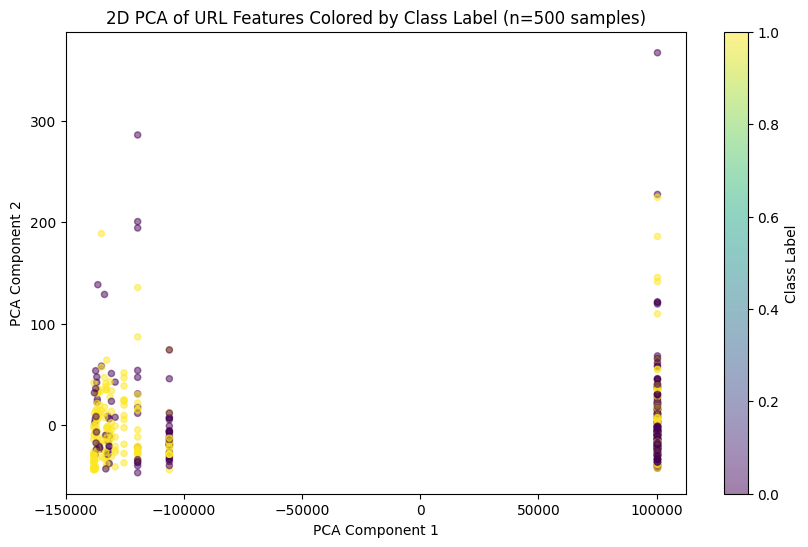

[[154015  84553]
 [ 59030 128492]]


In [5]:
# Output X_full (2-dimensional since it's PCA'd), color-code according to y_full labels
# Downsample to 500 random points (reproducible)
n_samples = min(500, len(X_full))
rng = np.random.default_rng(42)
idx = rng.choice(len(X_full), size=n_samples, replace=False)
X_samp = X_full.iloc[idx]
y_samp = y_full.iloc[idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_samp[0], X_samp[1], c=y_samp, cmap='viridis', s=20, alpha=0.5)
plt.colorbar(label='Class Label')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'2D PCA of URL Features Colored by Class Label (n={n_samples} samples)')
plt.show()

region_mask = (X_full.iloc[:, 0] > 50000) & (X_full.iloc[:, 1] < 1000000000)

# use positional boolean mask
mask_values = region_mask.to_numpy()

# top-left (both PCA components negative)
tl_counts = (
    y_full.iloc[mask_values]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

# everything else
other_counts = (
    y_full.iloc[~mask_values]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

mtx = np.array([
    [tl_counts[0], tl_counts[1]],
    [other_counts[0], other_counts[1]],
]).astype(int)


print(mtx) # seems to be about the same accuracy as the logreg...

In [7]:
# Get r^2 of each feature vs. output label
for col in X_full.columns:
    corr = np.corrcoef(X_full[col], y_full)[0, 1]
    print(f"Correlation between {col} and output label: {corr}")

Correlation between 0 and output label: -0.3395298583005803
Correlation between 1 and output label: -0.05395011846924408
Correlation between 2 and output label: -0.054107292834170345


In [8]:
if TEST_MODE:
    # Output the proportion of benign vs. malicious that have https vs http
    https_counts = DF_full.groupby(['is_https', 'type']).size().unstack(fill_value=0)
    print("\nHTTPS vs HTTP counts:")
    print(https_counts)

# Preprocessing Experiments
Goal: Get an idea of how the dataset looks, so we can do a better job of processing it.

In [9]:
# Get the percentage of BENIGN and MALICIOUS URLs that have more/less than 100,000 TLD frequency
if TEST_MODE:
    tld_threshold = 6500
    benign_above_threshold = DF_full[(DF_full['type'] == 0) & (DF_full['TLD_freq'] > tld_threshold)].shape[0]
    benign_below_threshold = DF_full[(DF_full['type'] == 0) & (DF_full['TLD_freq'] <= tld_threshold)].shape[0]
    malicious_above_threshold = DF_full[(DF_full['type'] == 1) & (DF_full['TLD_freq'] > tld_threshold)].shape[0]
    malicious_below_threshold = DF_full[(DF_full['type'] == 1) & (DF_full['TLD_freq'] <= tld_threshold)].shape[0]

    # calculate percentages
    total_benign = benign_above_threshold + benign_below_threshold
    total_malicious = malicious_above_threshold + malicious_below_threshold
    print(f"Total BENIGN URLs: {total_benign} ({total_benign / (total_benign + total_malicious) * 100:.2f}%)")
    print(f"Total MALICIOUS URLs: {total_malicious} ({total_malicious / (total_benign + total_malicious) * 100:.2f}%)")
    print()
    print(f"Percentage of BENIGN URLs above threshold: {benign_above_threshold / total_benign * 100:.2f}%")
    print(f"Percentage of BENIGN URLs below threshold: {benign_below_threshold / total_benign * 100:.2f}%")
    print(f"Percentage of MALICIOUS URLs above threshold: {malicious_above_threshold / total_malicious * 100:.2f}%")
    print(f"Percentage of MALICIOUS URLs below threshold: {malicious_below_threshold / total_malicious * 100:.2f}%")
    print()
    # Print the percentage of URLs above threshold that are benign vs malicious
    total_above_threshold = benign_above_threshold + malicious_above_threshold
    print(f"Percentage of URLs above threshold that are BENIGN: {benign_above_threshold / total_above_threshold * 100:.2f}%")
    print(f"Percentage of URLs above threshold that are MALICIOUS: {malicious_above_threshold / total_above_threshold * 100:.2f}%")

In [10]:
#print the 10 most common TLDs in the dataset, in order of frequency

if TEST_MODE:
    tld_counts = DF_full['TLD'].value_counts().head(20)
    print("20 most common TLDs:")
    output = "["
    bool = False
    for tld, count in tld_counts.items():
        if bool:
            output += ", "
        bool = True
        output += f"'{tld}': {count}"
        print(f"{tld}: {count}")

    output += "]"
    print(output)

# LogReg Training and Evaluation

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)


In [15]:
# Test my data prep strategy using pre-built libraries...

# Train logistic regression model
logreg = LogisticRegression(max_iter=1000,solver='lbfgs',C=1.0,penalty='l2')
#print(X_train.head())
logreg.fit(X_train, y_train)

# Predict and evaluate
decision_threshold = 0.50
y_pred_proba = logreg.predict_proba(X_test)[:,1] # get the probabilities of being in positive class
y_pred = (y_pred_proba >= decision_threshold).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# output confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(np.round(cm*100/np.sum(cm), 2))
print(cm)

Accuracy: 0.6594381468703795
              precision    recall  f1-score   support

           0       0.64      0.72      0.68     42523
           1       0.68      0.60      0.64     42695

    accuracy                           0.66     85218
   macro avg       0.66      0.66      0.66     85218
weighted avg       0.66      0.66      0.66     85218

Confusion Matrix:
[[35.86 14.04]
 [20.02 30.08]]
[[30562 11961]
 [17061 25634]]


In [ ]:
# Create ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_prob = logreg.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()